# Estimating $H_0$ and $\Omega_h$ Metrapolis-Hastings Markov Chain Monte Carlo

using the Type 1a SNe from Pantheon data


---

## Defining Cosmological distances

In [6]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

h = 0.71          
H0 = 100 * h          # in km/s/Mpc
c = 299792.458        # in km/s
Omega_m = 0.3         # Note: Omega_m + Omega_Lambda = 1.0, which means the universe is "flat"
Omega_Lambda = 0.7    # and Omega_r is approximately 0

def H(z):
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

def integrand(z):
    return c / H(z)

def comoving_distance(z):
    integral, error = integrate.quad(integrand, 0, z)
    return integral

def angular_diameter_distance(z):
    D_c = comoving_distance(z)
    return D_c / (1 + z)

def luminosity_distance(z):
    D_c = comoving_distance(z)
    return D_c * (1 + z)

def physical_distance(z):
    return comoving_distance(z) / (1 + z)

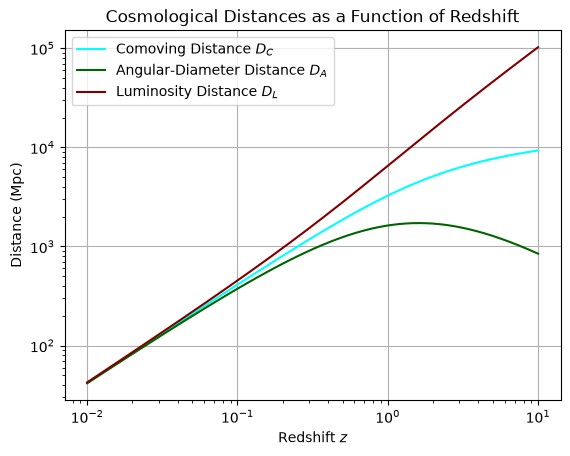

In [7]:
# We want lots of points close to z=0 (where things change fast) and
# fewer points out at high z (where things change more slowly), so we
# build the array in three chunks and glue them together

z_values_1 = np.linspace(0.01, 0.1, 200)
z_values_2 = np.linspace(0.1, 1, 200)
z_values_3 = np.linspace(1, 10, 200)
z_values = np.concatenate((z_values_1, z_values_2, z_values_3))
 
# Calculating the integral to find D_c values::
D_c_values = np.array([comoving_distance(z) for z in z_values])
 
# Once we already have D_c_values for every redshift, we write:
# D_A=1/(1+z)*integral(c/H(z)) not integral(c/{H(z)*(1+z)})
D_A_values = D_c_values / (1 + z_values)  
D_L_values = D_c_values * (1 + z_values)
 
# Plotting
plt.plot(z_values, D_c_values, label='Comoving Distance $D_C$', color='cyan') #plt.figure(figsize=(6, 3))
plt.plot(z_values, D_A_values, label='Angular-Diameter Distance $D_A$', color="darkgreen")
plt.plot(z_values, D_L_values, label='Luminosity Distance $D_L$', color='maroon')

plt.xscale('log')  
plt.yscale('log') 
 
plt.xlabel('Redshift $z$') 
plt.ylabel('Distance (Mpc)')
plt.title('Cosmological Distances as a Function of Redshift')
plt.legend()
plt.grid(True)
plt.show()

We will plot the theoritical distance modulus for the parameters, that we set in the starting.

And see how our parametric model agrees with the observed pantheon data.


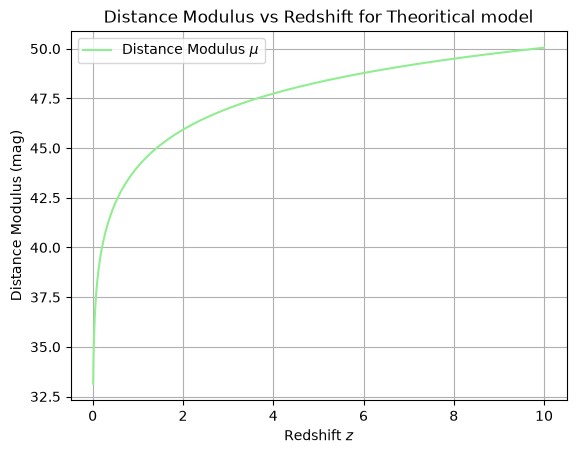

In [8]:

mu_values = 5 * np.log10(D_L_values) + 25

plt.plot(z_values, mu_values, label='Distance Modulus $\\mu$', color='lightgreen')

plt.xlabel('Redshift $z$')
plt.ylabel('Distance Modulus (mag)')
plt.title('Distance Modulus vs Redshift for Theoritical model')
plt.legend()
plt.grid(True)
plt.show()

# on logarithmic scale, plot will be straight line with slope 5

In [9]:
data = pd.read_csv("Pantheon_SNdata.csv")

print(data.head)

<bound method NDFrame.head of        #name     zcmb     zhel  dz        mb      dmb  dist_mod
0     2002cr  0.01012  0.01012   0  13.90745  0.19825  33.25745
1     2002dp  0.01038  0.01038   0  14.04960  0.20480  33.39960
2     2009an  0.01043  0.01043   0  13.92480  0.20035  33.27480
3     2006bh  0.01082  0.01082   0  14.00860  0.18445  33.35860
4     1998dk  0.01209  0.01209   0  13.97910  0.19140  33.32910
...      ...      ...      ...  ..       ...      ...       ...
1043   Primo  1.55000  1.55000   0  26.00705  0.18565  45.35705
1044    geta  1.70000  1.70000   0  26.05920  0.28320  45.40920
1045   stone  1.80000  1.80000   0  26.20110  0.18795  45.55110
1046  wilson  1.91400  1.91400   0  26.16090  0.25590  45.51090
1047  colfax  2.26000  2.26000   0  26.87700  0.25480  46.22700

[1048 rows x 7 columns]>


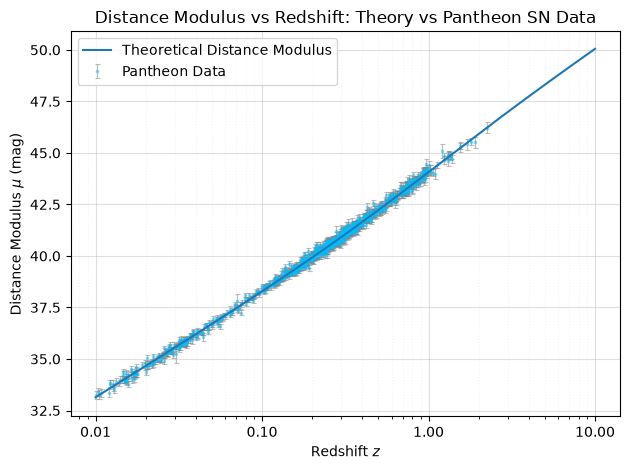

In [10]:
plt.plot(z_values, mu_values, label='Theoretical Distance Modulus', zorder=2)
 
plt.errorbar(
    data['zcmb'], data['dist_mod'], yerr=data['dmb'],
    fmt='o', mfc='deepskyblue', mec='none', ms=2.5,
    ecolor='gray', alpha=0.5,
    capsize=1.8, capthick=0.8, elinewidth=0.9,
    label='Pantheon Data', zorder=1
)
 
plt.xscale('log')
ax = plt.gca()
ax.set_xticks([0.01, 0.1, 1, 10])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
 
plt.xlabel('Redshift $z$')
plt.ylabel(r'Distance Modulus $\mu$ (mag)')
plt.title('Distance Modulus vs Redshift: Theory vs Pantheon SN Data')
plt.legend()
plt.grid(True, which='both', alpha=0.3)

ax.grid(True, which='major', alpha=0.4)
ax.grid(True, which='minor', alpha=0.15, linestyle=':')
 
plt.tight_layout()
plt.show()

#### Defining necessary functions for the mh mcmc method and data representation

In [11]:
def plot_hist_with_gaussian(data, param_name, bins=50, color='#7F77DD'):
    """Histogram of MCMC samples with a fitted Gaussian overlay."""
    data = np.asarray(data)
 
    # Fit a Gaussian: returns (mean, std) that best match the sample distribution
    mu, sigma = stats.norm.fit(data)
 
    fig, ax = plt.subplots(figsize=(6, 4))
 
    # density=True normalizes the histogram so its area = 1, matching the
    # Gaussian pdf's area — otherwise the curve and bars are on different scales
    counts, bin_edges, _ = ax.hist(data, bins=bins, density=True,
                                    color=color, alpha=0.6,
                                    edgecolor='white', linewidth=0.3,
                                    label='MCMC samples')
 
    x = np.linspace(data.min(), data.max(), 300)
    pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, color='black', lw=2,
            label=f'Gaussian fit\n$\\mu$={mu:.7f}, $\\sigma$={sigma:.7f}')
 
    ax.axvline(mu, color='red', linestyle='--', lw=0.8)
 
    ax.set_xlabel(param_name)
    ax.set_ylabel('Probability density')
    ax.set_title(f'Posterior distribution: {param_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()
 
    return mu, sigma

In [12]:
#Defining Chi squared function

def chi_sq(obs, theo, err):
    obs= np.array(obs)
    theo=np.array(theo)
    err=np.array(err)
    chi_squared=np.sum(((obs-theo)/err)**2)
    return chi_squared

## MH-MCMC method for finding H_0 and Ωm

In [13]:


# Define the Distance ModulusFunction again to take Ω_m and H0 values
def Hubble(z, H0 = H0, omega_m = Omega_m ):
    return H0 * np.sqrt(omega_m * (1 + z)**3 + 1 - omega_m)

def integrand2(z, H0, omega_m):
    return c / Hubble(z, H0, omega_m)

def DISTANCE_MODULUS(z, H0, omega_m):
    D_c, error = integrate.quad(integrand2, 0, z, args=(H0, omega_m))
    D_L = D_c * (1 + z)
    return 5*np.log10(D_L) + 25


# Calculate omega_m_new, H0_new for each iteration, also checks if new points are in range
def CALCULATE_NEW(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range):
    omega_m_new = omega_m_previous + delta_omega_m * np.random.normal(0, 1)
    H0_new = H0_previous + delta_H0 * np.random.normal(0, 1)
    if omega_m_range[0] <= omega_m_new <= omega_m_range[1] and H0_range[0] <= H0_new <= H0_range[1]:
        return omega_m_new, H0_new
    else:
        return CALCULATE_NEW(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range)
    


In [ ]:

# define some constants. parameters
omega_m_range = [0.15, 0.45]
H0_range = [55, 85]
delta_omega_m = 0.005
delta_H0 = 0.2
print(f'\u03A9_m range:{omega_m_range}, \u0394\u03A9_m:{delta_omega_m},\nH0 range:{H0_range}, \u0394H0:{delta_H0}')

N_iterations =40000 

Ω_m range:[0.15, 0.45], ΔΩ_m:0.005,
H0 range:[55, 85], ΔH0:0.2


In [15]:
# Metropolis Hastings - Markov chain Monte Carlo, to constrain Ω_m and H0
mcmc_df = pd.DataFrame(columns=['Omega_m', 'H0', 'Chi_sq', 'Type'])

# choose initial parameters randomly in the range
omega_m_initial = np.random.uniform(low=omega_m_range[0], high=omega_m_range[1])
H0_initial = np.random.uniform(low=H0_range[0], high=H0_range[1])

print("omega_m_initial, H0_initial:", omega_m_initial, H0_initial)

chi_sqr = chi_sq(data['dist_mod'] , [DISTANCE_MODULUS(z, H0_initial, omega_m_initial) for z in data['zcmb']], data['dmb'] )
print("Chi_squared initial:",chi_sq,'\n')

# ------------------------------------------------------------------------------ #

print("Begin MH-MCMC\n")
omega_m_previous = omega_m_initial
H0_previous = H0_initial
chi_sq1 = chi_sqr

for n in range(N_iterations):

    omega_m_new, H0_new = CALCULATE_NEW(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range)
    chi_sq2 = chi_sq(data['dist_mod'] , [DISTANCE_MODULUS(z, H0_new, omega_m_new) for z in data['zcmb']], data['dmb'] )

    if (chi_sq2 <= chi_sq1):
        omega_m_previous = omega_m_new
        H0_previous = H0_new
        chi_sq1 = chi_sq2
        type_val = 1
        mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]
        print(f'{n})-- type 1, omega_m: {omega_m_previous}, H0 = {H0_previous}, chi_sq: {chi_sq1}')
    else:
        nrand = np.random.uniform(0,1)
        prob_ratio = np.exp(-(chi_sq2 - chi_sq1) / 2)
        if prob_ratio > nrand:
            omega_m_previous = omega_m_new
            H0_previous = H0_new
            chi_sq1 = chi_sq2
            type_val = 2
            mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]
            print(f'{n}) -- type 2, omega_m: {omega_m_previous}, H0 = {H0_previous}, chi_sq: {chi_sq1}')
        else:
            type_val = 3

    # mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]


print("\nomega_m_Final, H0_Final:", omega_m_previous, H0_previous)
print('Final Chi_sq value:', chi_sq1)


omega_m_initial, H0_initial: 0.21199162251450165 65.88593953718468
Chi_squared initial: <function chi_sq at 0x77261e4f18a0> 

Begin MH-MCMC

0)-- type 1, omega_m: 0.2104316643081015, H0 = 66.03006226395192, chi_sq: 2660.7358946245613
2)-- type 1, omega_m: 0.20348964481564188, H0 = 66.22609298639638, chi_sq: 2608.022356509873
4)-- type 1, omega_m: 0.20054864083396304, H0 = 66.35815879172873, chi_sq: 2556.745031167041
7)-- type 1, omega_m: 0.20295822966466692, H0 = 66.398614552635, chi_sq: 2508.582478281568
9)-- type 1, omega_m: 0.20310501175750192, H0 = 66.77778410458892, chi_sq: 2290.8525910997128
10)-- type 1, omega_m: 0.20119176598065172, H0 = 67.44715034630276, chi_sq: 1970.2758603026007
17)-- type 1, omega_m: 0.1980317189792937, H0 = 67.80371871615289, chi_sq: 1837.3536647609203
21)-- type 1, omega_m: 0.19649160755734596, H0 = 67.86371629609667, chi_sq: 1823.8350265195204
23)-- type 1, omega_m: 0.1975755031458118, H0 = 68.19077608814578, chi_sq: 1686.4451794854685
25)-- type 1, ome

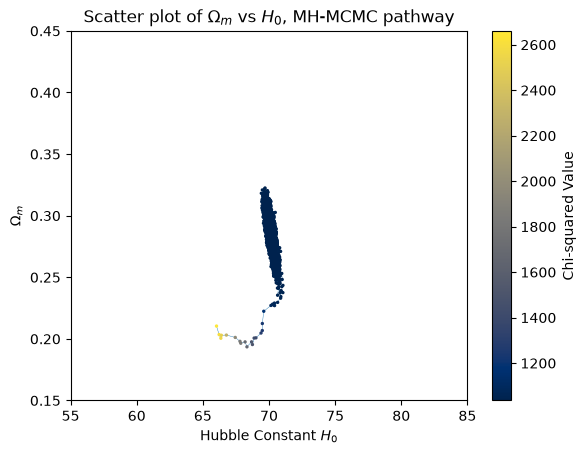

In [16]:
# Scatter plot of Ω_m vs H_0 MH-MCMC pathway
plt.plot(mcmc_df['H0'], mcmc_df['Omega_m'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df['H0'], mcmc_df['Omega_m'], c=mcmc_df['Chi_sq'], cmap='cividis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_m$')
plt.title('Scatter plot of $\u03A9_m$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_m_range[0], omega_m_range[1])

plt.show()

In [17]:
print(mcmc_df.head())

#Trim mcmc values to remove burnt values
final_chi_sq = mcmc_df['Chi_sq'].iloc[-1]
# Find the first row where Chi_sq is less than the threshold
first_valid_index = mcmc_df[mcmc_df['Chi_sq'] < 1.05*final_chi_sq].index[0]
print(first_valid_index)

# Trim the DataFrame from the first valid index onward
mcmc_df = mcmc_df.iloc[first_valid_index:].reset_index(drop=True)

print(mcmc_df)


    Omega_m         H0       Chi_sq  Type
0  0.210432  66.030062  2660.735895   1.0
1  0.203490  66.226093  2608.022357   1.0
2  0.200549  66.358159  2556.745031   1.0
3  0.202958  66.398615  2508.582478   1.0
4  0.203105  66.777784  2290.852591   1.0
19
        Omega_m         H0       Chi_sq  Type
0      0.228183  70.272209  1085.254043   1.0
1      0.227523  70.342836  1081.300757   1.0
2      0.229068  70.409527  1074.131306   1.0
3      0.227026  70.418959  1077.131672   2.0
4      0.229646  70.651996  1061.938242   1.0
...         ...        ...          ...   ...
10842  0.278288  70.361355  1036.598830   2.0
10843  0.281400  70.343910  1036.761091   2.0
10844  0.276341  70.214041  1036.354169   1.0
10845  0.277044  70.302272  1036.105793   1.0
10846  0.271858  70.265208  1037.064743   2.0

[10847 rows x 4 columns]


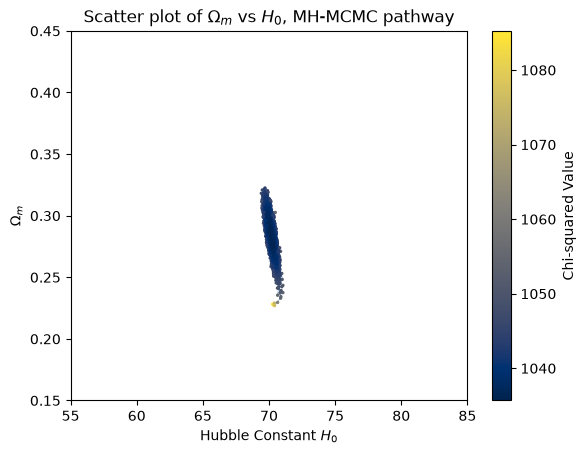

In [18]:
# Scatter plot of Ω_m vs H_0 MH-MCMC pathway
plt.plot(mcmc_df['H0'], mcmc_df['Omega_m'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df['H0'], mcmc_df['Omega_m'], c=mcmc_df['Chi_sq'], cmap='cividis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_m$')
plt.title('Scatter plot of $\u03A9_m$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_m_range[0], omega_m_range[1])

plt.show()

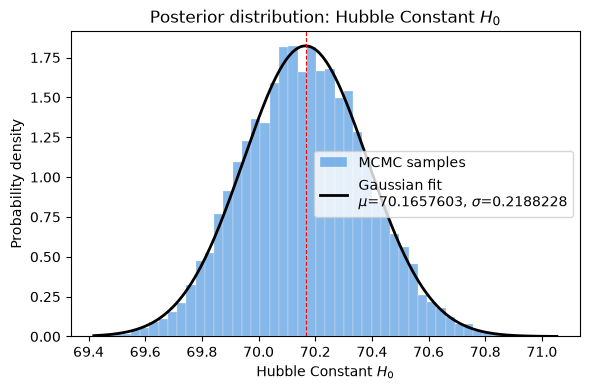

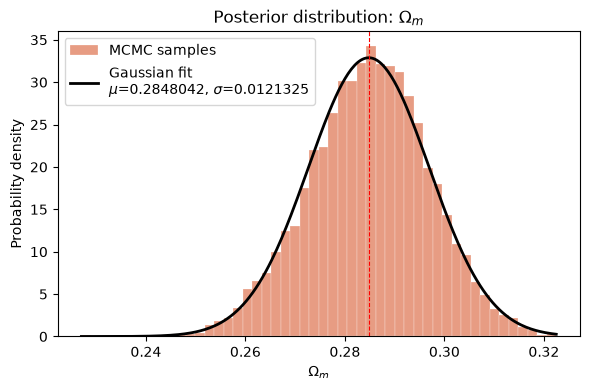

H0     = 70.17 +/- 0.22 km/s/Mpc
Omega_m = 0.285 +/- 0.012


In [19]:
H0_mean, H0_std = plot_hist_with_gaussian(mcmc_df['H0'], 'Hubble Constant $H_0$',
                                           color='#378ADD')
Om_mean, Om_std = plot_hist_with_gaussian(mcmc_df['Omega_m'], '$\\Omega_m$',
                                           color='#D85A30')
 
print(f"H0     = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")

In [20]:
import corner

figure = corner.corner(data1, labels=labels, show_titles=True, quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 1},
                       title_fmt=".2f", color='green', hist_kwargs={"color": "lightblue"})

NameError: name 'data1' is not defined

## MCMC for 3 parameters (H_0, Omega_m and Omega_r)

In [ ]:
def Hubble3(z, H0, omega_m, omega_r):
    return H0 * np.sqrt(omega_r * (1 + z)**4
                        + omega_m * (1 + z)**3
                        + (1 - omega_m - omega_r))

def integrand3(z, H0, omega_m, omega_r):
    return c / Hubble3(z, H0, omega_m, omega_r)

def DISTANCE_MODULUS3(z, H0, omega_m, omega_r):
    D_c, _ = integrate.quad(integrand3, 0, z, args=(H0, omega_m, omega_r))
    D_L = D_c * (1 + z)
    return 5 * np.log10(D_L) + 25

def CALCULATE_NEW3(omega_m_prev, H0_prev, omega_r_prev,
                   domega_m, dH0, domega_r,
                   omega_m_range, H0_range, omega_r_range):
    omega_m_new = omega_m_prev + domega_m * np.random.normal(0, 1)
    H0_new = H0_prev + dH0 * np.random.normal(0, 1)
    omega_r_new = omega_r_prev + domega_r * np.random.normal(0, 1)
    if (omega_m_range[0] <= omega_m_new <= omega_m_range[1]
        and H0_range[0] <= H0_new <= H0_range[1]
        and omega_r_range[0] <= omega_r_new <= omega_r_range[1]):
        return omega_m_new, H0_new, omega_r_new
    return CALCULATE_NEW3(omega_m_prev, H0_prev, omega_r_prev, domega_m, dH0, domega_r,
                          omega_m_range, H0_range, omega_r_range)

In [ ]:
omega_r_range = [0, 0.005]
delta_omega_r = 10**-5

mcmc_df3 = pd.DataFrame(columns=['H0', 'Omega_m', 'Omega_r', 'Chi_sq', 'Type'])

omega_m_prev = np.random.uniform(*omega_m_range)
H0_prev = np.random.uniform(*H0_range)
omega_r_prev = np.random.uniform(*omega_r_range)
print(f'Initial values: Omega_m={omega_m_prev:.3f}, H0={H0_prev:.2f}, Omega_r={omega_r_prev*10**5:.3f}e-5')

chi_sq1 = chi_sq(data['dist_mod'],
                 [DISTANCE_MODULUS3(z, H0_prev, omega_m_prev, omega_r_prev) for z in data['zcmb']],
                 data['dmb'])

for nstep in range(N_iterations):
    omega_m_new, H0_new, omega_r_new = CALCULATE_NEW3(omega_m_prev, H0_prev, omega_r_prev,
                                                      delta_omega_m, delta_H0, delta_omega_r,
                                                      omega_m_range, H0_range, omega_r_range)
    chi_sq2 = chi_sq(data['dist_mod'],
                     [DISTANCE_MODULUS3(z, H0_new, omega_m_new, omega_r_new) for z in data['zcmb']],
                     data['dmb'])

    if chi_sq2 <= chi_sq1:
        omega_m_prev, H0_prev, omega_r_prev, chi_sq1 = omega_m_new, H0_new, omega_r_new, chi_sq2
        type_val = 1
        mcmc_df3.loc[len(mcmc_df3)] = [H0_prev, omega_m_prev, omega_r_prev, chi_sq1, type_val]
        print(f'{nstep}) -- type 1, omega_m: {omega_m_prev}, H0 = {H0_prev}, omega_r = {omega_r_prev}, chi_sq: {chi_sq1}')
    else:
        nrand = np.random.uniform(0, 1)
        prob_ratio = np.exp(-(chi_sq2 - chi_sq1) / 2)
        if prob_ratio > nrand:
            omega_m_prev, H0_prev, omega_r_prev, chi_sq1 = omega_m_new, H0_new, omega_r_new, chi_sq2
            type_val = 2
            mcmc_df3.loc[len(mcmc_df3)] = [H0_prev, omega_m_prev, omega_r_prev, chi_sq1, type_val]
            print(f'{nstep}) -- type 2, omega_m: {omega_m_prev}, H0 = {H0_prev}, omega_r = {omega_r_prev}, chi_sq: {chi_sq1}')
        else:
            type_val = 3
            # rejected — no append, no print

print("\nomega_m_Final, H0_Final, omega_r_Final:", omega_m_prev, H0_prev, omega_r_prev)
print('Final Chi_sq value:', chi_sq1)

Initial values: Omega_m=0.325, H0=59.22, Omega_r=225.298e-5
1) -- type 1, omega_m: 0.3298513244039831, H0 = 59.2602613366908, omega_r = 0.002247417094647075, chi_sq: 8046.7361873341415
2) -- type 1, omega_m: 0.3249115229757479, H0 = 59.433636469899625, omega_r = 0.002252093336812039, chi_sq: 7870.680241616331
3) -- type 1, omega_m: 0.32487783170727125, H0 = 59.663087547564515, omega_r = 0.002258212564190503, chi_sq: 7541.304939309022
4) -- type 1, omega_m: 0.3268907562049485, H0 = 59.78665394600077, omega_r = 0.0022765402731134156, chi_sq: 7336.503428476606
5) -- type 1, omega_m: 0.32469792756014093, H0 = 59.88911964282977, omega_r = 0.0022748162066229603, chi_sq: 7227.965472645379
6) -- type 1, omega_m: 0.3208465592427203, H0 = 60.379765616345345, omega_r = 0.0022730464609151237, chi_sq: 6628.77963884336
7) -- type 1, omega_m: 0.32498266698808237, H0 = 60.3983327849947, omega_r = 0.002252689455264256, chi_sq: 6545.975924114311
8) -- type 1, omega_m: 0.3267350971696041, H0 = 60.4309395

In [ ]:
#Trim mcmc values to remove burnt values
final_chi_sq = mcmc_df3['Chi_sq'].iloc[-1]
# Find the first row where Chi_sq is less than the threshold
first_valid_index = mcmc_df3[mcmc_df3['Chi_sq'] < 1.05*final_chi_sq].index[0]

In [ ]:
plt.plot(mcmc_df3['H0'], mcmc_df3['Omega_r'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df3['H0'], mcmc_df3['Omega_r'], c=mcmc_df3['Chi_sq'], cmap='cividis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_r$')
plt.title('Scatter plot of $\u03A9_r$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_r_range[0], omega_r_range[1])

plt.show()

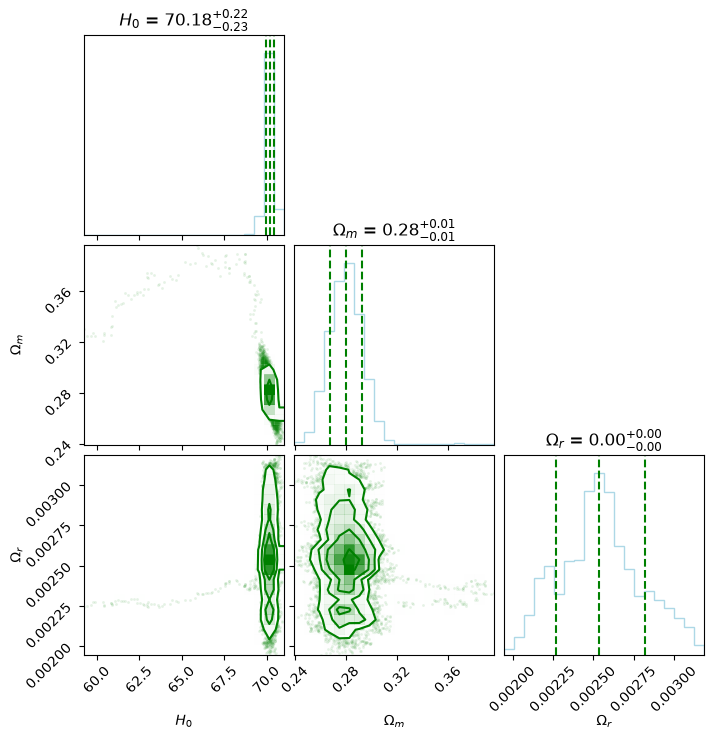

In [ ]:
figure = corner.corner(samples, labels=labels, show_titles=True, quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12},
                       title_fmt=".2f", color='green', hist_kwargs={"color": "lightblue"})

In [ ]:
H0_mean, H0_std = plot_hist_with_gaussian(mcmc_df3['H0'], 'Hubble Constant $H_0$',
                                           color='#378ADD')
Om_mean, Om_std = plot_hist_with_gaussian(mcmc_df3['Omega_m'], '$\\Omega_m$',
                                           color='#D85A30')
Or_mean, Or_std = plot_hist_with_gaussian(mcmc_df3['Omega_r'], '$\\Omega_r$',
                                           color='#4CAF50')

print(f"H0      = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")
print(f"Omega_r = {Or_mean:.7f} +/- {Or_std:.7f}")